In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from utils import *
import sklearn.cluster as cluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from scipy.stats import multivariate_normal,f

# 1. Dendrogram Comparison
Compare the dendrogram of non-randomized hierarchical clustering and  randomized algorithms with varying level of randomization

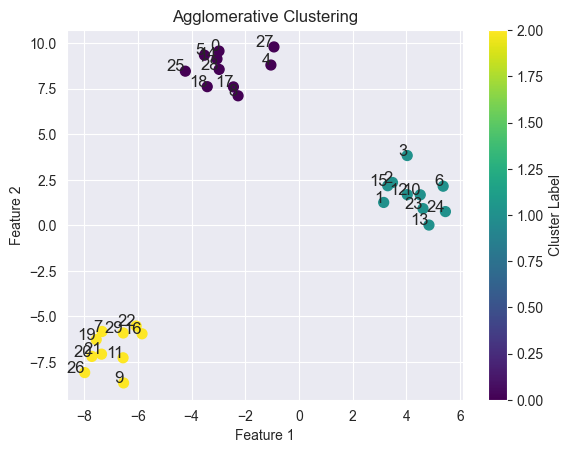

In [10]:
# Generate a dataset with 3 true clusters
X, y = make_blobs(n_samples=30, centers=3, cluster_std=1,random_state=42)
plt.scatter(X[:, 0], X[:, 1], s=50, c=y, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

## 1. Non-randomized hierarchical clustering
### a. using sklearn.cluster

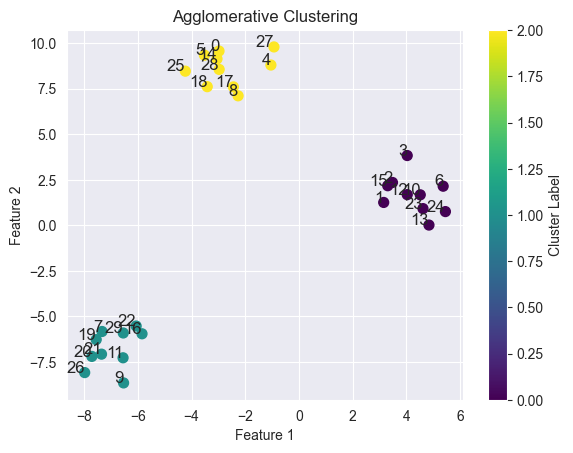

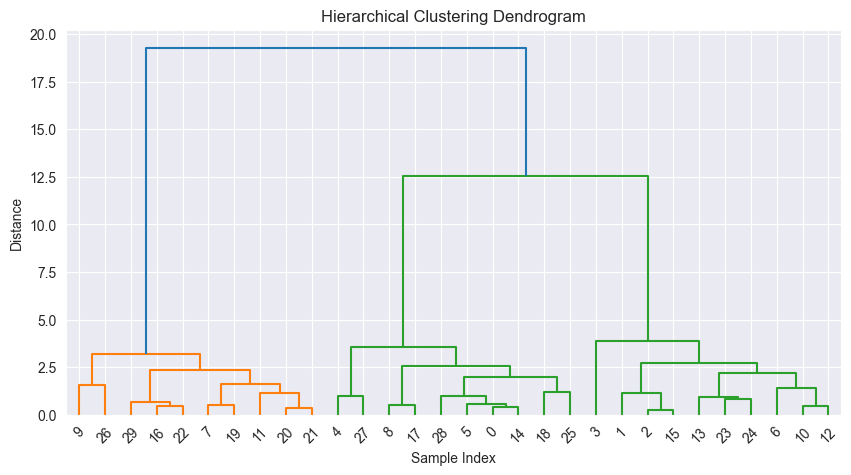

In [11]:
# Non-randomized hierarchical clustering using sklearn.cluster
model = cluster.AgglomerativeClustering(n_clusters=3, linkage='complete')
labels_sklearn = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], s=50, c=labels_sklearn, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')
plt.show()

Z = linkage(X, method='complete') 
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

### b. using our function with tau=0

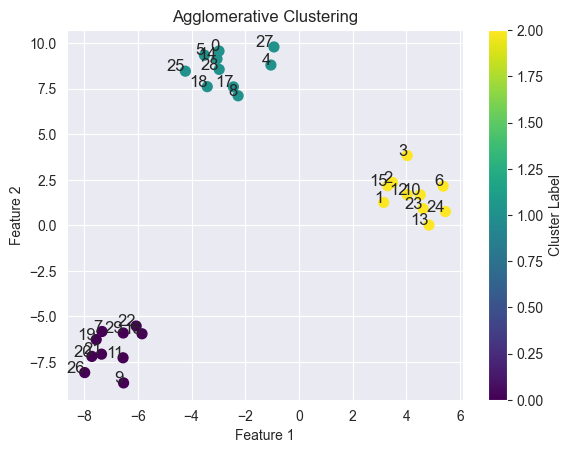

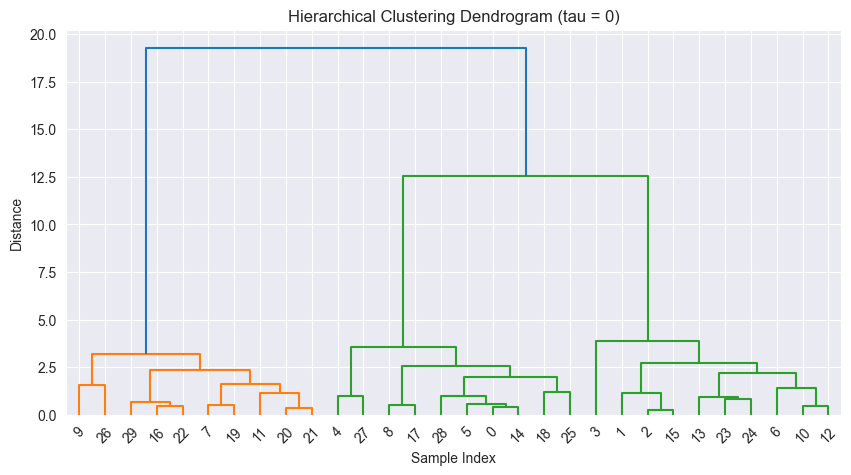

In [12]:
# Non-randomized clustering using our function
model = AgglomerativeClustering(X, tau=0, n_clusters=3,linkage="complete")
model.fit(dendrogram=True)
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)
for idx, node in enumerate(model.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

model.plot_dendrogram()

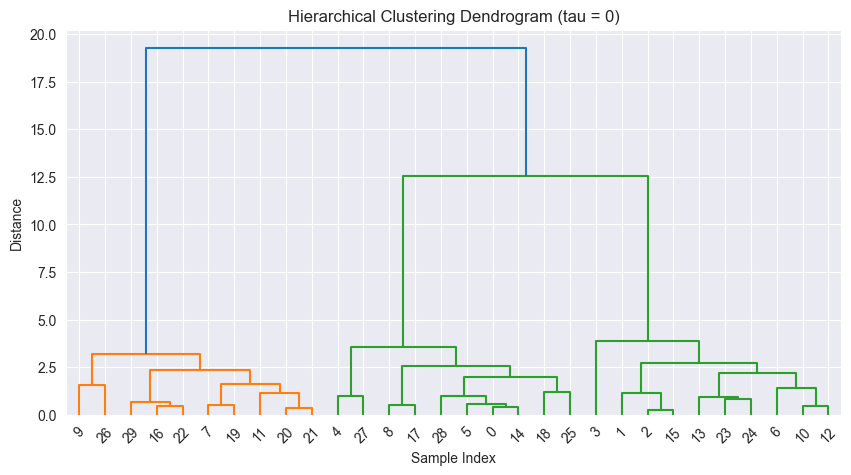

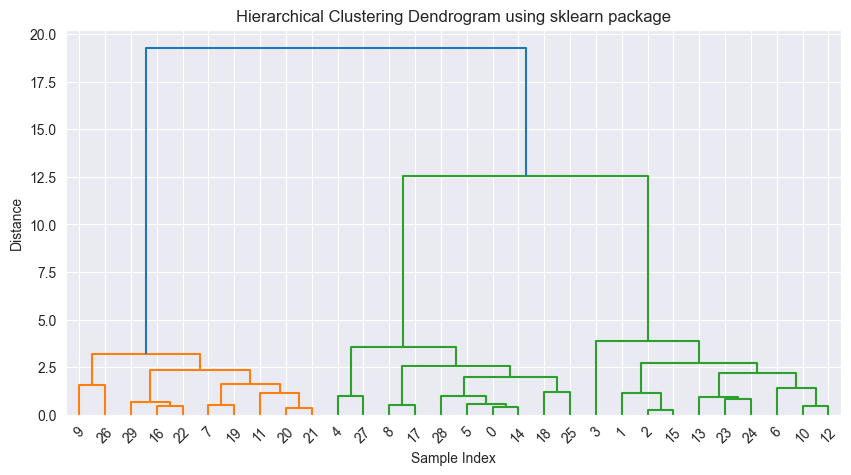

In [13]:
model.plot_dendrogram()

Z = linkage(X, method='complete') 
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram using sklearn package")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

## 2. Randomized Hierarchical Clustering Dendrograms

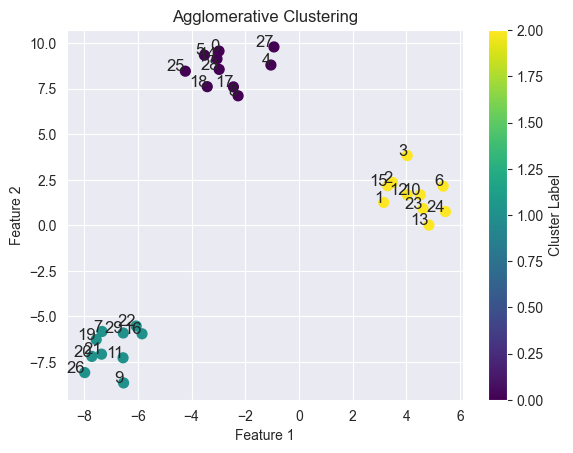

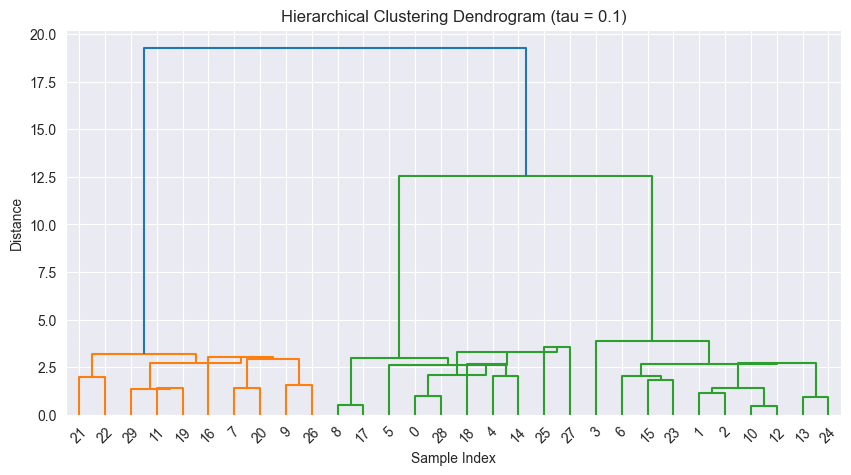

In [19]:
# tau=0.1
model01 = AgglomerativeClustering(X, tau=0.1, n_clusters=3,linkage="complete")
model01.fit(dendrogram=True)
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)
for idx, node in enumerate(model01.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

model01.plot_dendrogram()

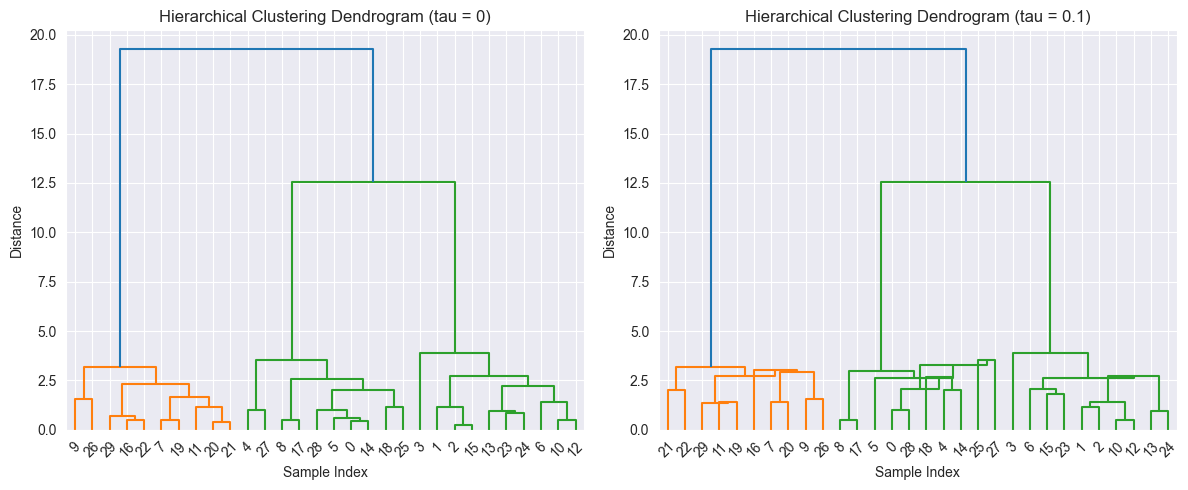

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model.plot_dendrogram(ax=axes[0], show=False)
model01.plot_dendrogram(ax=axes[1], show=False)
plt.tight_layout()
plt.show()

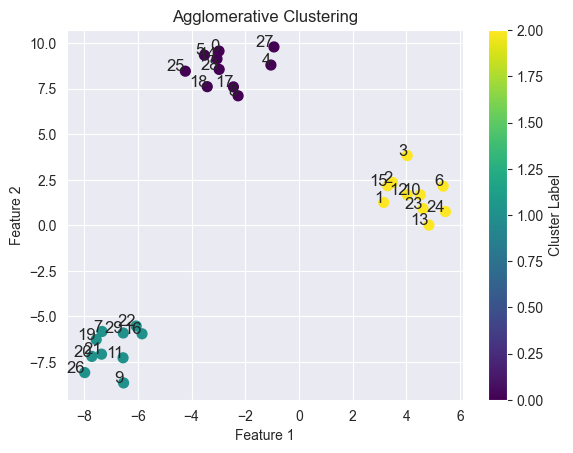

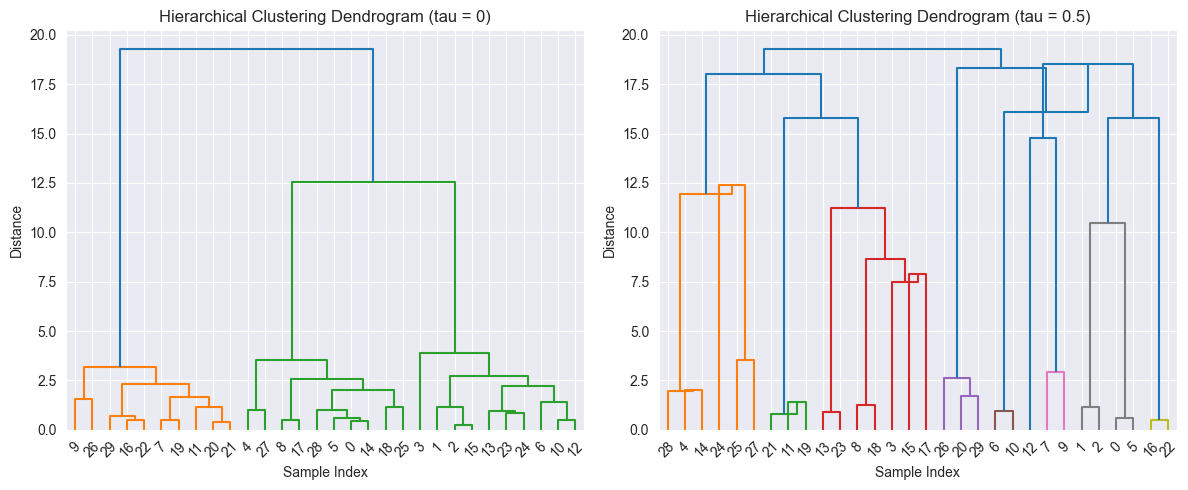

In [18]:
# tau=0.1
model05 = AgglomerativeClustering(X, tau=0.5, n_clusters=3,linkage="complete")
model05.fit(dendrogram=True)
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)
for idx, node in enumerate(model01.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model.plot_dendrogram(ax=axes[0], show=False)
model05.plot_dendrogram(ax=axes[1], show=False)
plt.tight_layout()
plt.show()


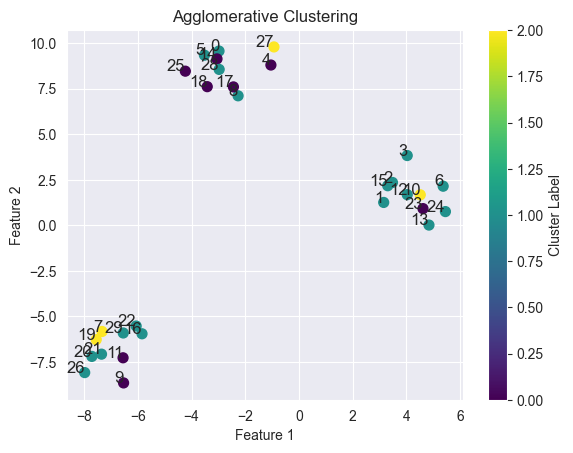

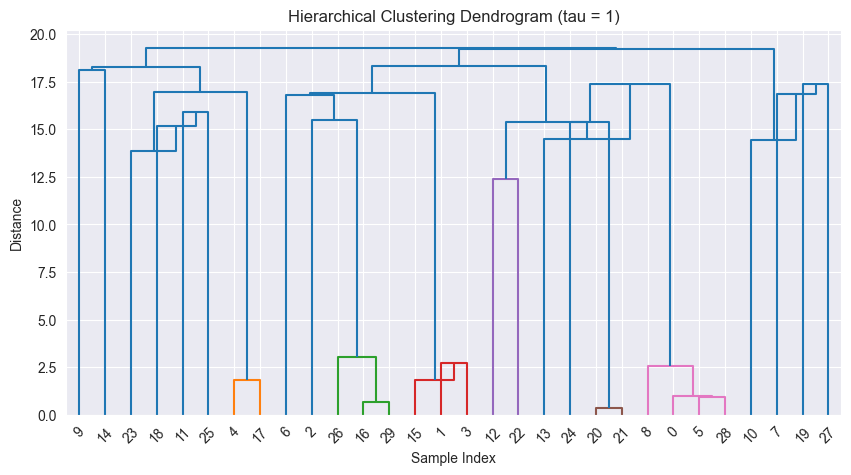

In [17]:
# tau=1
model1 = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="complete")
model1.fit(dendrogram=True)
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)
for idx, node in enumerate(model1.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

model1.plot_dendrogram()

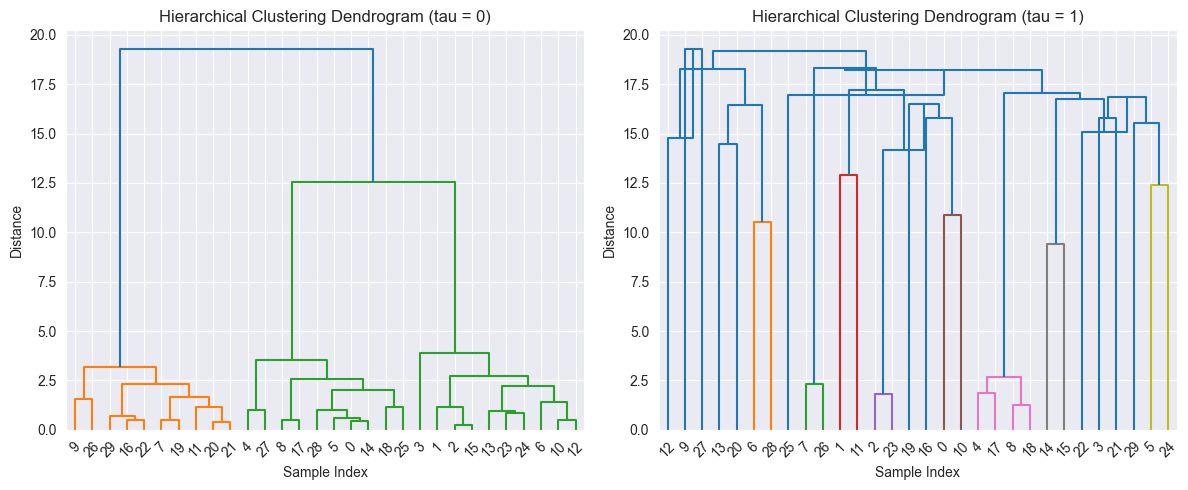

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model.plot_dendrogram(ax=axes[0], show=False)
model1.plot_dendrogram(ax=axes[1], show=False)
plt.tight_layout()
plt.show()

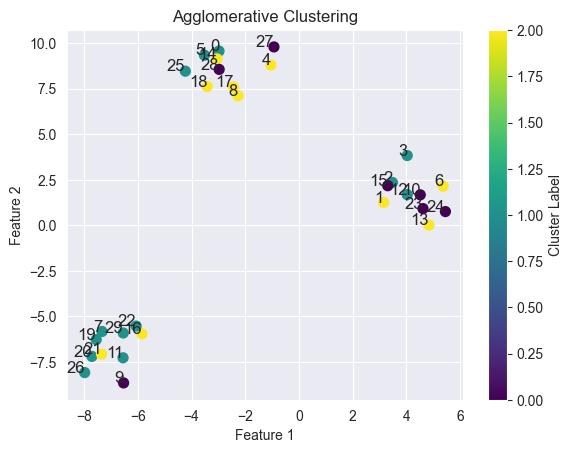

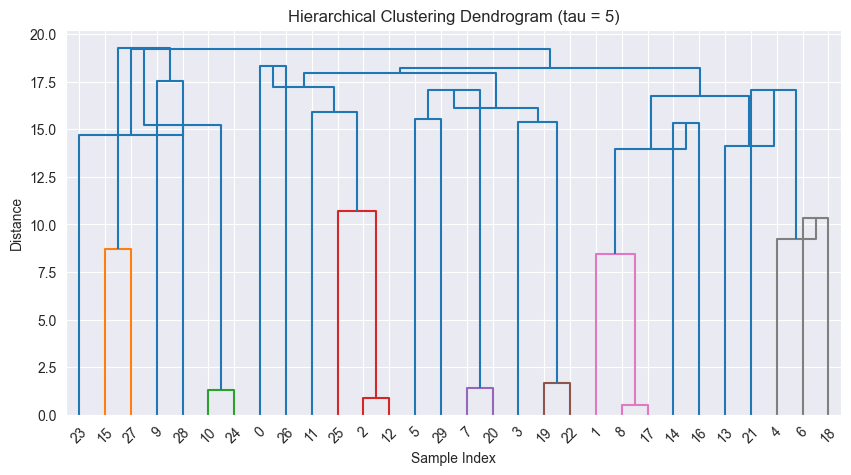

In [10]:
# tau=5
model5 = AgglomerativeClustering(X, tau=5, n_clusters=3,linkage="complete")
model5.fit(dendrogram=True)
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)
for idx, node in enumerate(model5.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

model5.plot_dendrogram()

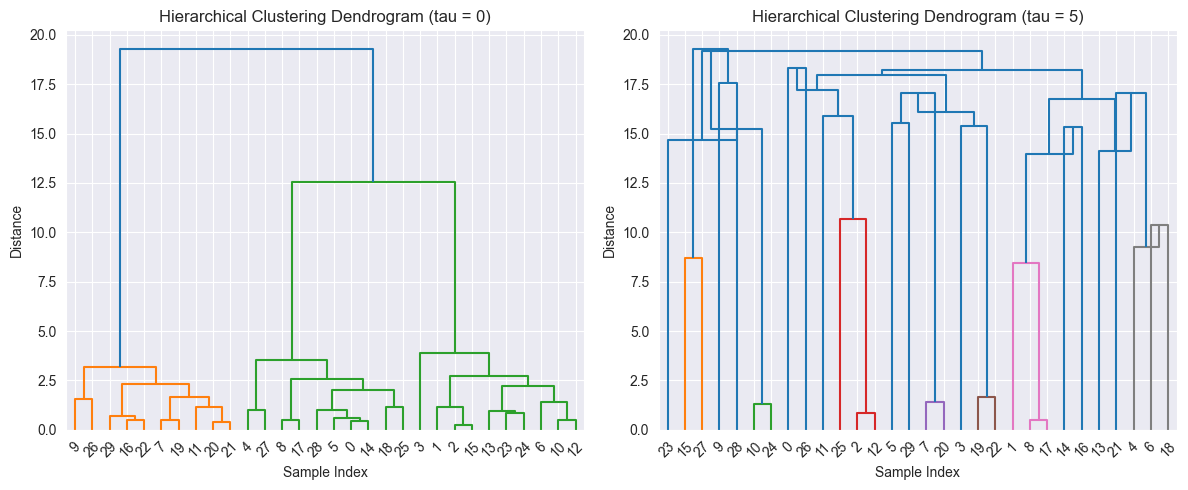

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model.plot_dendrogram(ax=axes[0], show=False)
model5.plot_dendrogram(ax=axes[1], show=False)
plt.tight_layout()
plt.show()

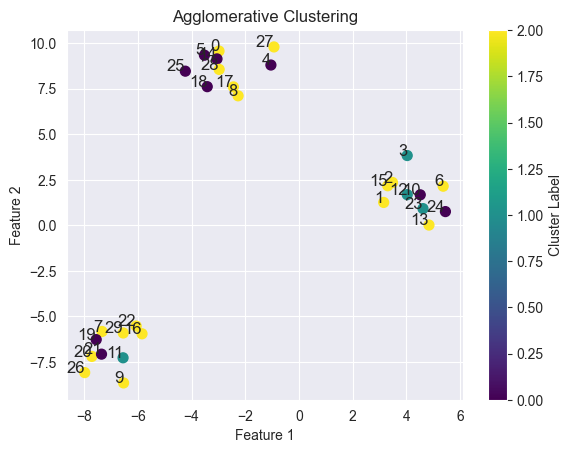

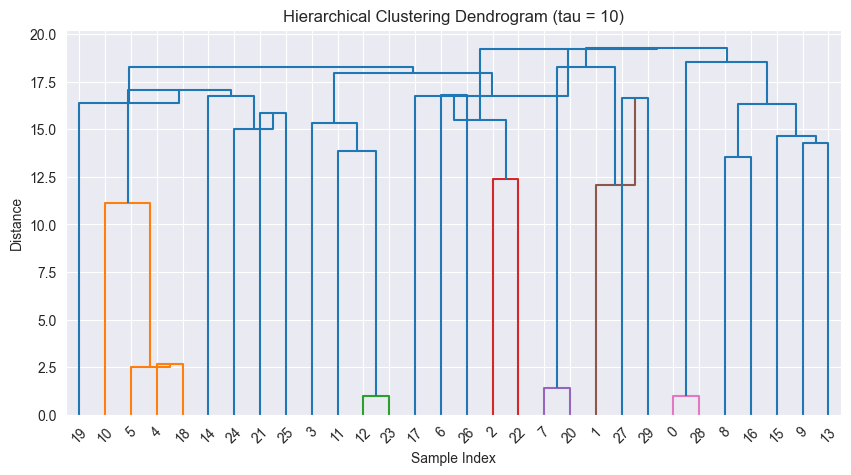

In [12]:
# tau=10
model10 = AgglomerativeClustering(X, tau=10, n_clusters=3,linkage="complete")
model10.fit(dendrogram=True)
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)
for idx, node in enumerate(model10.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

model10.plot_dendrogram()

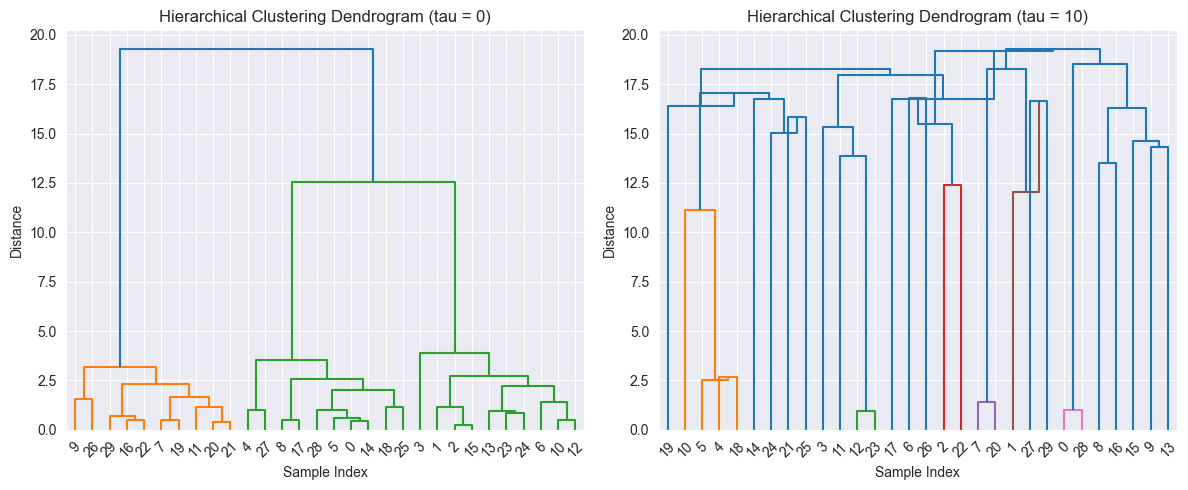

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model.plot_dendrogram(ax=axes[0], show=False)
model10.plot_dendrogram(ax=axes[1], show=False)
plt.tight_layout()
plt.show()

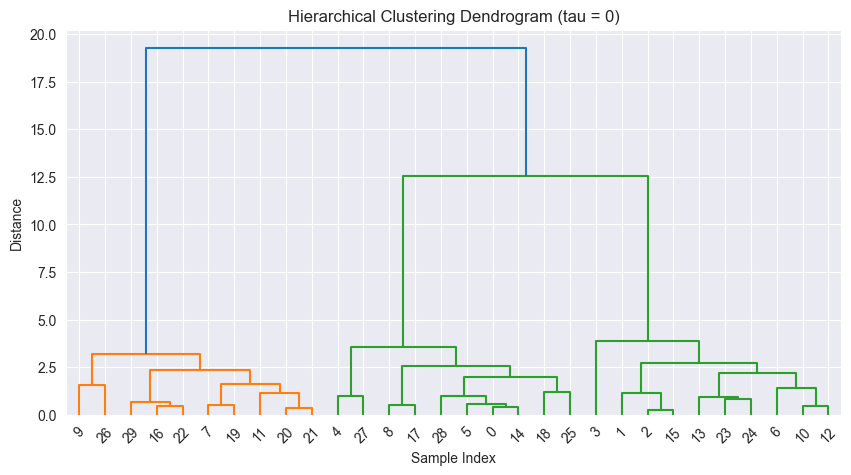

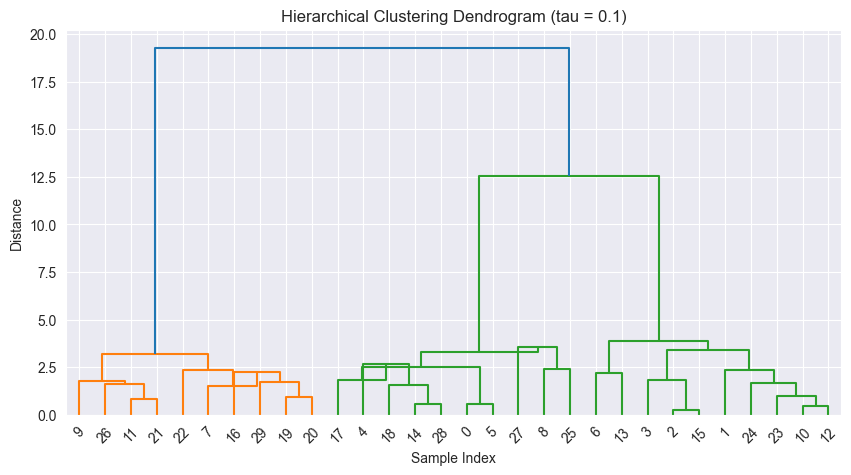

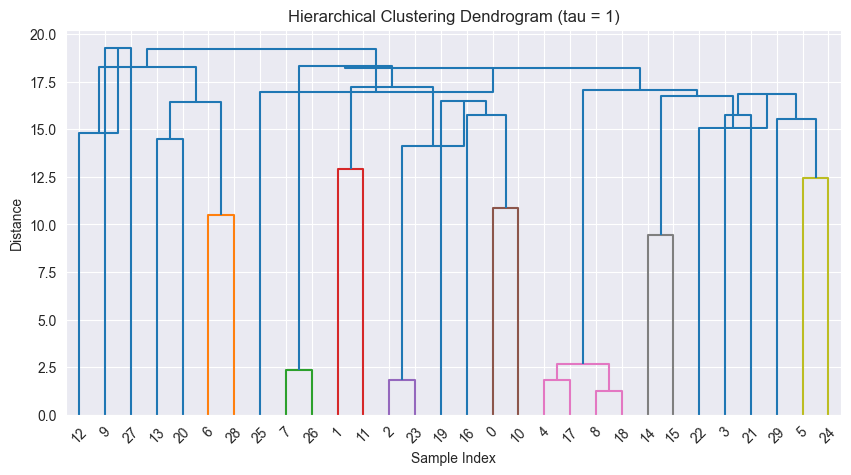

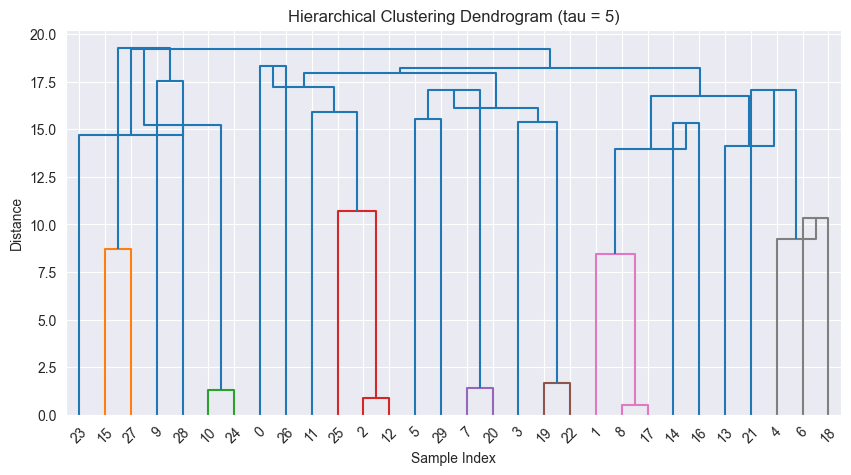

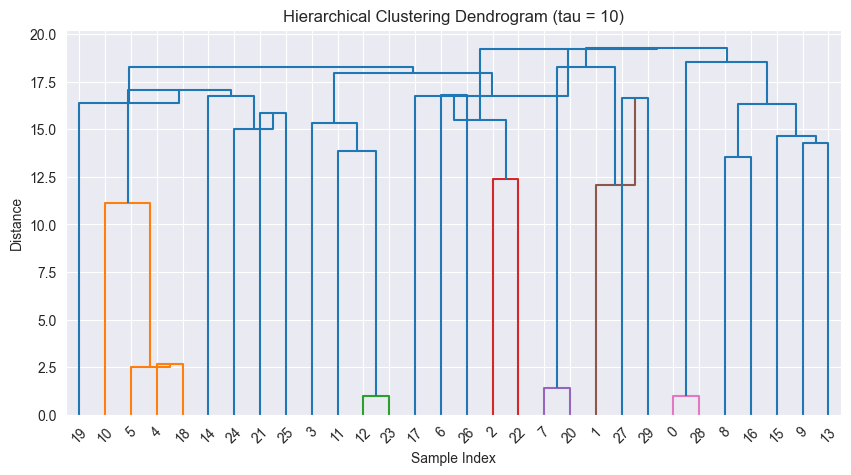

In [14]:
model.plot_dendrogram()
model01.plot_dendrogram()
model1.plot_dendrogram()
model5.plot_dendrogram()
model10.plot_dendrogram()

# 2. Performance Comparison
## a. WCSS and BCSS

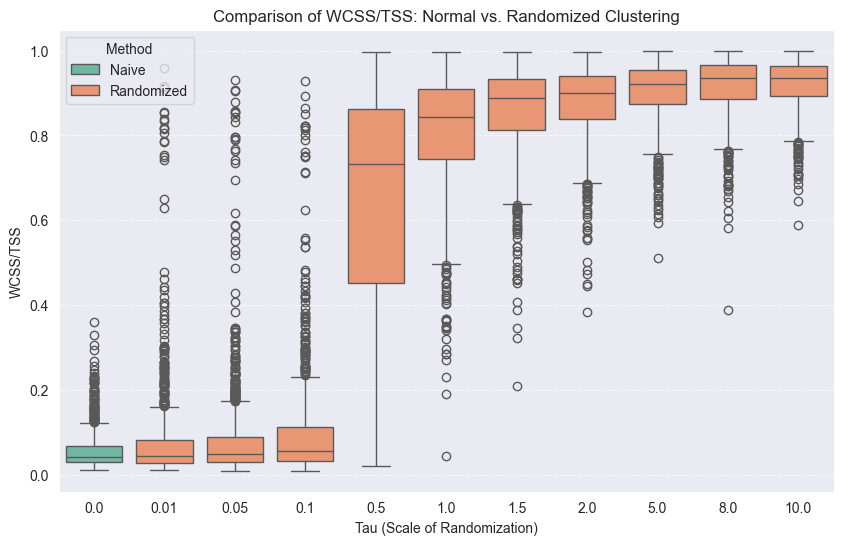

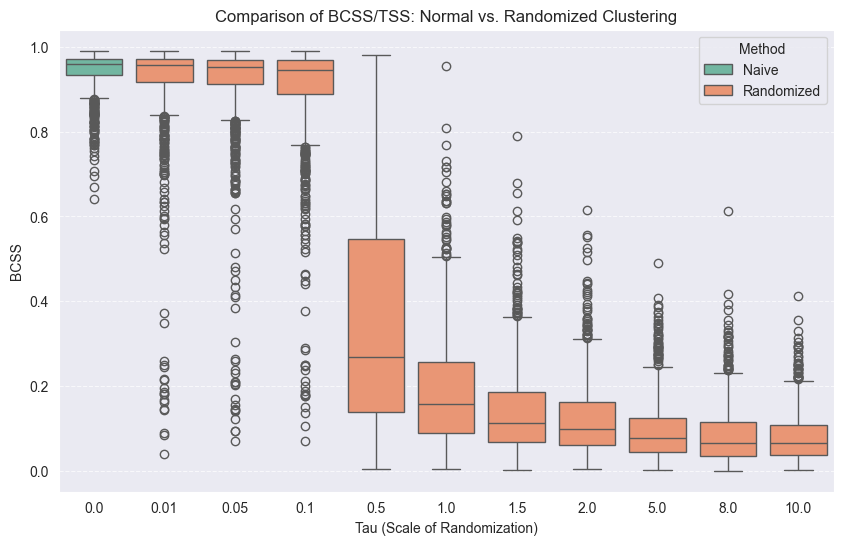

In [6]:
n = 30
tau_values = [0,0.01,0.05, 0.1,0.5,1,1.5,2,5,8,10]
n_runs = 1000
n_clusters = 3
# Data collection
results = []
bcss = []
for tau in tau_values:
    for _ in range(n_runs):
        X, y = make_blobs(n_samples=n, centers=3, cluster_std=1)
        tss = np.sum((X - np.mean(X, axis=0)) ** 2)
        if tau != 0:
            # Randomized hierarchical clustering
            randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            randomized_clustering.fit()
            randomized_score = randomized_clustering.compute_wcss()
            bcss_score = randomized_clustering.compute_bcss()
            results.append({'Tau': tau, 'Method': 'Randomized', 'WCSS/TSS': randomized_score / tss})
            bcss.append({'Tau': tau, 'Method': 'Randomized', 'BCSS/TSS': bcss_score / tss})
        else:
            naive = cluster.AgglomerativeClustering(n_clusters=n_clusters)
            naive_labels = naive.fit_predict(X)
            naive_score = 0
            for k in range(n_clusters):
                cluster_points = X[naive_labels == k]
                if len(cluster_points) > 0:
                    center = np.mean(cluster_points, axis=0)
                    naive_score += np.sum((cluster_points - center) ** 2)
            results.append({'Tau': tau, 'Method': "Naive", 'WCSS/TSS': naive_score / tss})
            bcss.append({'Tau': tau, 'Method': "Naive", 'BCSS/TSS': (tss - naive_score) / tss})

# Convert results to a DataFrame
df = pd.DataFrame(results)
df_bcss = pd.DataFrame(bcss)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='WCSS/TSS', hue='Method', palette='Set2')
plt.title('Comparison of WCSS/TSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('WCSS/TSS')
plt.legend(title='Method',loc = 'upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_bcss, x='Tau', y='BCSS/TSS', hue='Method', palette='Set2')
plt.title('Comparison of BCSS/TSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('BCSS')
plt.legend(title='Method',loc = 'upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### b. rand index
The **Adjusted Rand Index (ARI)** between two clusterings \( U \) and \( V \) is defined as:


$$
\text{ARI} = \frac{
    \sum_{ij} \binom{n_{ij}}{2}
    - \left[ \sum_i \binom{a_i}{2} \sum_j \binom{b_j}{2} \middle/ \binom{n}{2} \right]
}{
    \frac{1}{2} \left[ \sum_i \binom{a_i}{2} + \sum_j \binom{b_j}{2} \right]
    - \left[ \sum_i \binom{a_i}{2} \sum_j \binom{b_j}{2} \middle/ \binom{n}{2} \right]
}
$$

Where:
- $ n_{ij} $: number of elements in both cluster $ i $ of $ U $ and cluster $ j $ of $ V $
- $a_i = \sum_j n_{ij} $: size of cluster $ i $ in $ U $
- $ b_j = \sum_i n_{ij} $: size of cluster $ j $ in $ V $
- $ n $: total number of data points

In [16]:
import random
from sklearn.metrics import adjusted_rand_score
# Parameters
n = 100
fractions = [1.0,0.9,0.5,0.3,0.1]
n_clusters = 3
n_runs = 1000
results = []


for frac in fractions:
    for _ in range(n_runs):
        X, y_true = make_blobs(n_samples=n, centers=n_clusters, cluster_std=1)

        # Subsample
        subset_size = int(frac * n)
        idx = sorted(random.sample(range(n), subset_size))
        X_sub = X[idx]
        y_sub = y_true[idx]

        # Naive clustering (non-random)
        model = AgglomerativeClustering(X_sub, n_clusters=n_clusters, tau=0)
        model.fit()
        labels_pred = model.get_cluster_labels()

        ari = adjusted_rand_score(y_sub, labels_pred)
        results.append({'Fraction': frac, 'ARI': ari})

df_ari = pd.DataFrame(results)

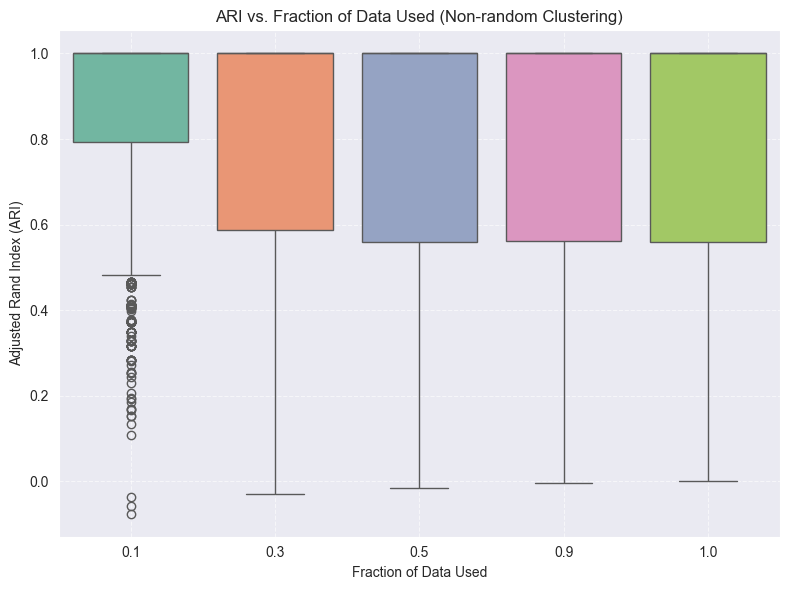

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_ari, x='Fraction', y='ARI', hue='Fraction', palette='Set2', legend=False)
plt.title('ARI vs. Fraction of Data Used (Non-random Clustering)')
plt.xlabel('Fraction of Data Used')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

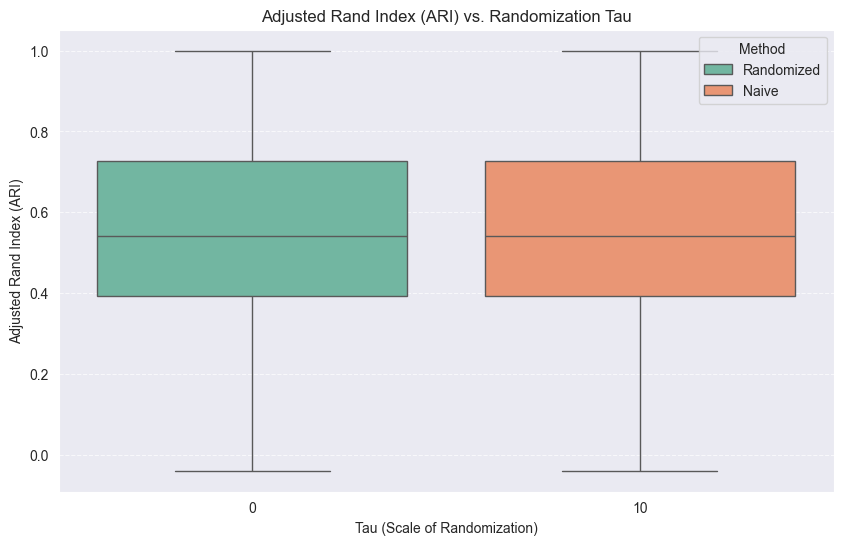

In [18]:

from sklearn.metrics import adjusted_rand_score
# cluster std = 1
n = 30
tau_values = [0,0.01,0.5,1,1.5,2,5,8,10]
n_runs = 1000
n_clusters = 3
results = []

for _ in range(n_runs):
    X, y_true = make_blobs(n_samples=n, centers=3, cluster_std=3)
            # Randomized hierarchical clustering
    randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=0)
    randomized_clustering.fit()
    labels_pred = randomized_clustering.get_cluster_labels()
    method = 'Randomized'

    results.append({'Tau': 0, 'Method': method, 'ARI': ari})
    naive = cluster.AgglomerativeClustering( n_clusters=n_clusters)
    labels_pred = naive.fit_predict(X)
    method = 'Naive'

    ari = adjusted_rand_score(y_true, labels_pred)
    results.append({'Tau': tau, 'Method': method, 'ARI': ari})
df_ari = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ari, x='Tau', y='ARI', hue='Method', palette='Set2')
plt.title('Adjusted Rand Index (ARI) vs. Randomization Tau')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.legend(title='Method', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

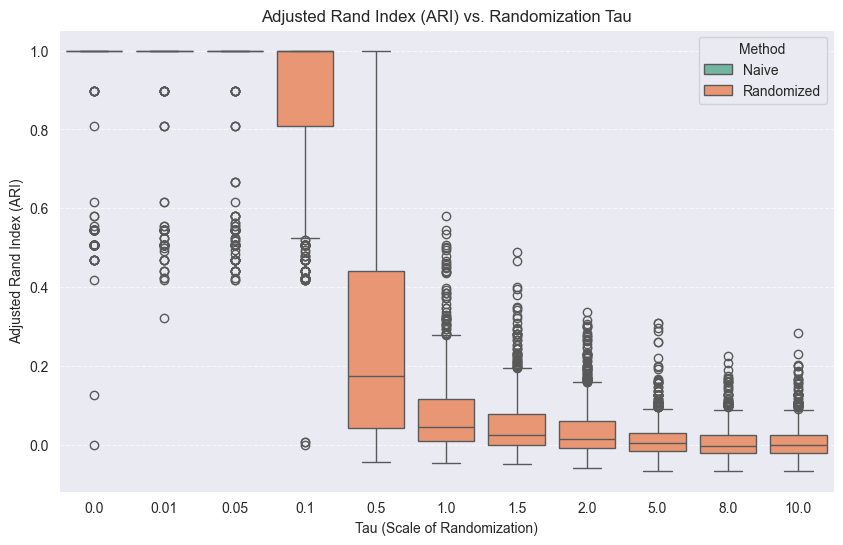

In [9]:

from sklearn.metrics import adjusted_rand_score
# cluster std = 1
n = 30
tau_values = [0,0.01,0.05, 0.1,0.5,1,1.5,2,5,8,10]
n_runs = 1000
n_clusters = 3
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y_true = make_blobs(n_samples=n, centers=3, cluster_std=0.5)

        if tau != 0:
            # Randomized hierarchical clustering
            randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            randomized_clustering.fit()
            labels_pred = randomized_clustering.get_cluster_labels()
            method = 'Randomized'
        else:
            naive = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            naive.fit()
            labels_pred = naive.get_cluster_labels()
            method = 'Naive'

        ari = adjusted_rand_score(y_true, labels_pred)
        results.append({'Tau': tau, 'Method': method, 'ARI': ari})
df_ari = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ari, x='Tau', y='ARI', hue='Method', palette='Set2')
plt.title('Adjusted Rand Index (ARI) vs. Randomization Tau')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.legend(title='Method', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

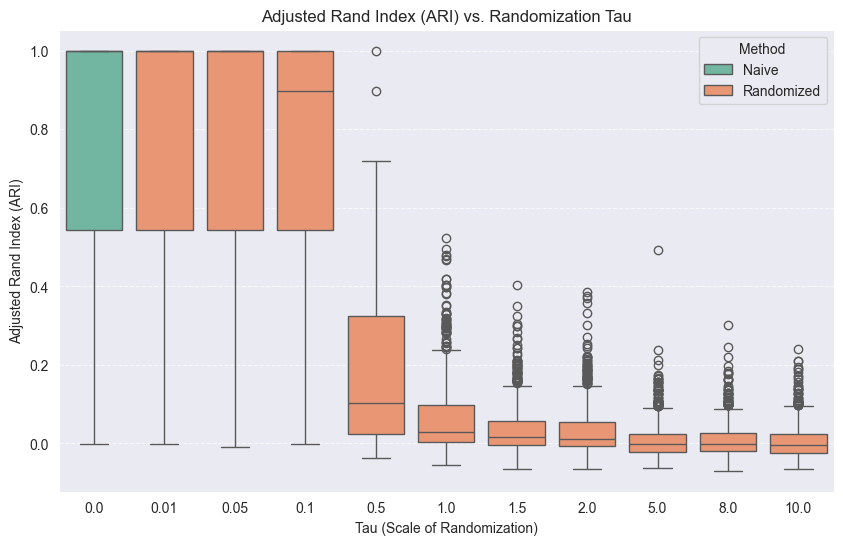

In [7]:

from sklearn.metrics import adjusted_rand_score
# cluster std = 1
n = 30
tau_values = [0,0.01,0.05, 0.1,0.5,1,1.5,2,5,8,10]
n_runs = 1000
n_clusters = 3
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y_true = make_blobs(n_samples=n, centers=3, cluster_std=1)

        if tau != 0:
            # Randomized hierarchical clustering
            randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            randomized_clustering.fit()
            labels_pred = randomized_clustering.get_cluster_labels()
            method = 'Randomized'
        else:
            naive = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            naive.fit()
            labels_pred = naive.get_cluster_labels()
            method = 'Naive'

        ari = adjusted_rand_score(y_true, labels_pred)
        results.append({'Tau': tau, 'Method': method, 'ARI': ari})
df_ari = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ari, x='Tau', y='ARI', hue='Method', palette='Set2')
plt.title('Adjusted Rand Index (ARI) vs. Randomization Tau')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.legend(title='Method', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

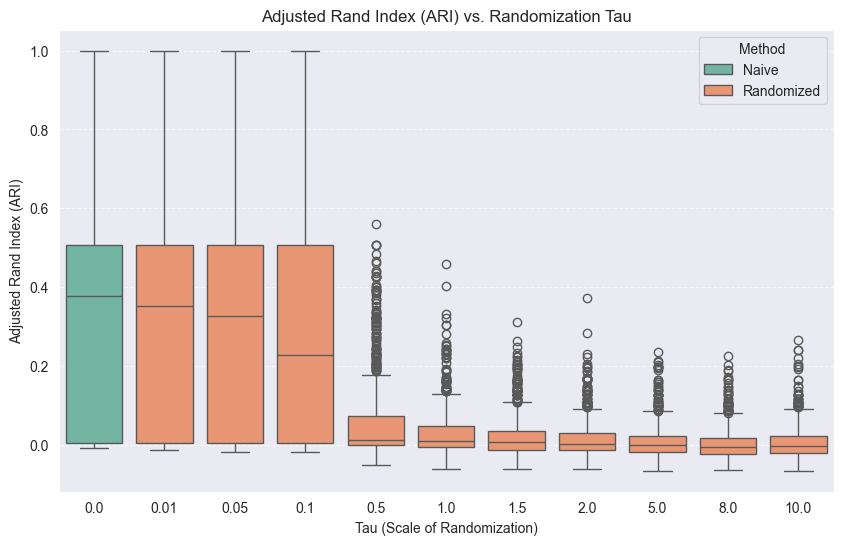

In [8]:
# cluster std = 3
n = 30
tau_values = [0,0.01,0.05, 0.1,0.5,1,1.5,2,5,8,10]
n_runs = 1000
n_clusters = 3
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y_true = make_blobs(n_samples=n, centers=3, cluster_std=3)

        if tau != 0:
            # Randomized hierarchical clustering
            randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            randomized_clustering.fit()
            labels_pred = randomized_clustering.get_cluster_labels()
            method = 'Randomized'
        else:
            naive = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            naive.fit()
            labels_pred = naive.get_cluster_labels()
            method = 'Naive'

        ari = adjusted_rand_score(y_true, labels_pred)
        results.append({'Tau': tau, 'Method': method, 'ARI': ari})
df_ari = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ari, x='Tau', y='ARI', hue='Method', palette='Set2')
plt.title('Adjusted Rand Index (ARI) vs. Randomization Tau')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.legend(title='Method', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. p-value Validility
## a. QQ Plot Comparison

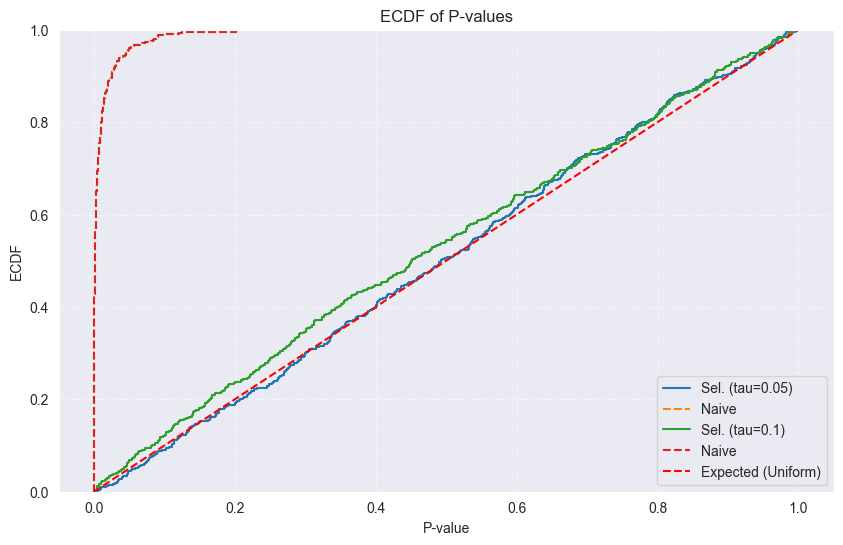

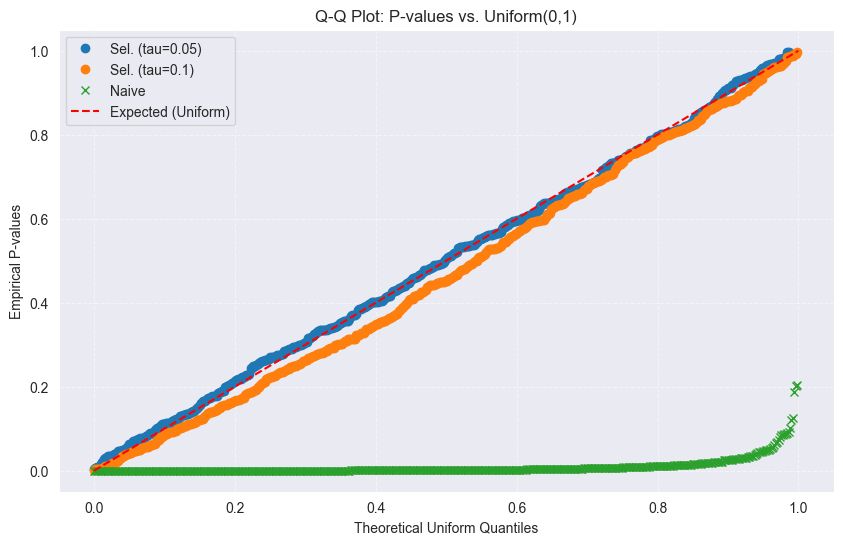

In [22]:
tau_list = np.array([0.05,0.1])
all_p_values, naive_p_values = check_p_value_uniformity_multi_tau_parallel(n=30, p=30, sigma=1, K=3, tau_list=tau_list, layer=-1,
                                                linkage="complete", num_trials=500, n_jobs=-1)
plt.figure(figsize=(10, 6))
for tau in tau_list:
    sns.ecdfplot(all_p_values[tau], label=f"Sel. (tau={tau})", linestyle="-")
    sns.ecdfplot(naive_p_values, label="Naive", linestyle="--")
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
plt.xlabel("P-value")
plt.ylabel("ECDF")
plt.title("ECDF of P-values")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(10, 6))
theoretical_quantiles = np.linspace(0, 1, 500)
for tau in tau_list:
    sorted_sel = np.sort(all_p_values[tau])
    plt.plot(theoretical_quantiles, sorted_sel, marker='o', linestyle='', label=f"Sel. (tau={tau})")
sorted_naive = np.sort(naive_p_values)
plt.plot(theoretical_quantiles, sorted_naive, marker='x', linestyle='', label="Naive")
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical P-values")
plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [23]:
tau_list = np.array([0.05,0.1,0.5,1,2,5,10])
check_p_value_uniformity_multi_tau_parallel(n=20, p=10, sigma=1, K=2, tau_list=tau_list, layer=-1,
                                                linkage="complete", num_trials=500, n_jobs=-1)

({np.float64(0.05): array([6.91503937e-01, 3.51668441e-01, 2.55795361e-01, 7.94118171e-01,
         3.16278533e-01, 4.06349414e-01, 7.99654252e-01, 5.98868383e-01,
         9.68518317e-01, 9.82548361e-01, 6.35399118e-01, 7.40026221e-01,
         7.65226442e-02, 4.72699910e-01, 0.00000000e+00, 6.46767322e-01,
         8.08599397e-02, 9.16612806e-01, 2.62949679e-01, 5.21101890e-01,
         5.71076106e-01, 8.84453278e-01, 1.05406740e-02, 2.65980293e-01,
         6.86922640e-01, 2.59814679e-01, 3.19102996e-01, 1.52901106e-02,
         6.57973445e-01, 1.86010736e-01, 7.26148335e-01, 4.41258584e-01,
         4.52046977e-01, 1.70361101e-01, 1.55508099e-01, 3.37815393e-01,
         3.73633856e-01, 1.53552496e-01, 4.83398915e-01, 4.03926435e-02,
         4.99790915e-01, 2.78709617e-01, 4.91232204e-01, 5.20897843e-01,
         5.76116912e-01, 2.35083360e-01, 2.35573748e-01, 1.39088409e-01,
         6.43118197e-01, 9.56229402e-01, 6.82909717e-01, 2.53565068e-01,
         6.50206149e-01, 2.604496

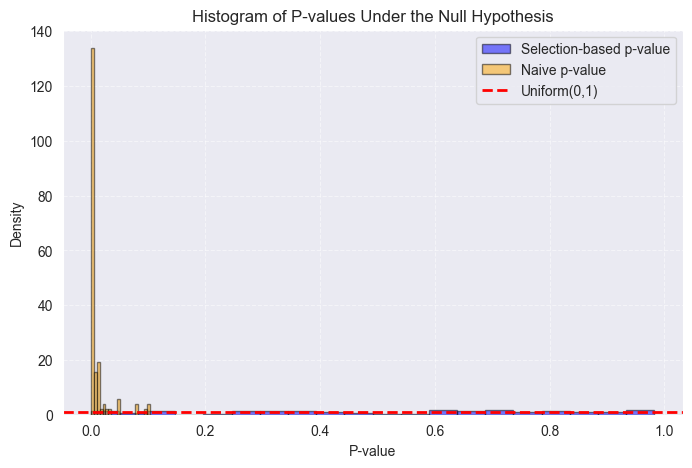

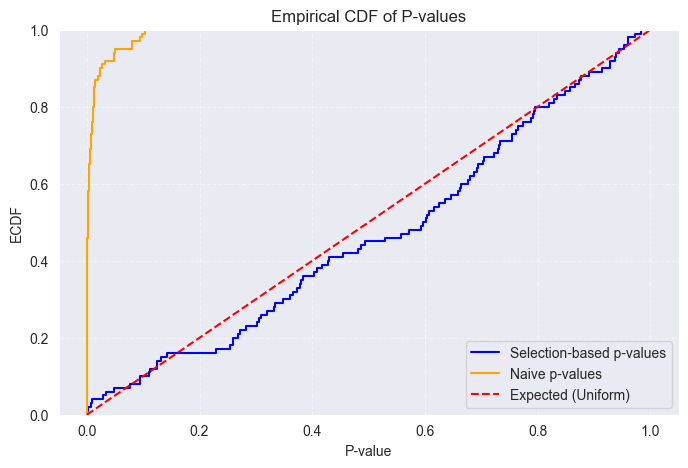

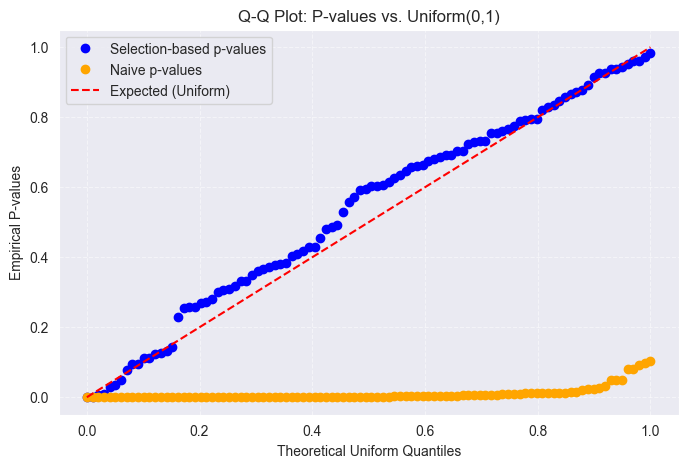

In [24]:
check_p_value_uniformity(30,30,1,3,1,-1,linkage= "complete",  num_trials=100)

## b. Type I error

# 4. Power